In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.linear_model import LogisticRegression
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

train_data = pd.read_csv("../csv/train.csv",  encoding='latin-1')

saleprice_summary = train_data["SalePrice"].describe()

# Calcular percentiles para definir los rangos de clasificación
q1 = train_data["SalePrice"].quantile(0.33)  # 33% más barato
q2 = train_data["SalePrice"].quantile(0.66)  # 66% intermedio
print(q1, q2,  train_data["SalePrice"].max())

# Crear la nueva variable categórica basada en los percentiles
train_data["PriceCategory"] = pd.cut(train_data["SalePrice"], 
                             bins=[train_data["SalePrice"].min(), q1, q2, train_data["SalePrice"].max()], 
                             labels=["Economica", "Media", "Cara"], #"Económica (0)", "Intermedia(1)", "Cara(2)" 
                             include_lowest=True)

# Mostrar resumen de la variable categórica creada
train_data[["PriceCategory", "SalePrice"]]

139000.0 189893.00000000006 755000


,PriceCategory,SalePrice
0,Cara,208500
1,Media,181500
2,Cara,223500
3,Media,140000
4,Cara,250000
...,...,...
1455,Media,175000
1456,Cara,210000
1457,Cara,266500
1458,Media,142125


In [2]:
train_data.shape

(1460, 82)

In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   object  
 3   LotFrontage    1201 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   object  
 6   Alley          91 non-null     object  
 7   LotShape       1460 non-null   object  
 8   LandContour    1460 non-null   object  
 9   Utilities      1460 non-null   object  
 10  LotConfig      1460 non-null   object  
 11  LandSlope      1460 non-null   object  
 12  Neighborhood   1460 non-null   object  
 13  Condition1     1460 non-null   object  
 14  Condition2     1460 non-null   object  
 15  BldgType       1460 non-null   object  
 16  HouseStyle     1460 non-null   object  
 17  OverallQual    1460 non-null   in

### Columnas que NO sirven:
- Id - identificador único, no aporta valor predictivo.

- Alley, PoolQC, Fence, MiscFeature - demasiados valores nulos (>75%).

- Utilities - tiene casi un solo valor (AllPub), no aporta variabilidad.

- FireplaceQu, GarageYrBlt, GarageQual, GarageCond - muchos nulos y posible colinealidad con otras características más completas.

In [4]:
train_data.drop(columns=["Id","Alley","PoolQC", "Fence", "MiscFeature", "Utilities", "FireplaceQu", "GarageYrBlt", "GarageQual", "GarageCond"],axis=1, inplace=True)

In [5]:
print(train_data.dtypes.tolist())

[dtype('int64'), dtype('O'), dtype('float64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('float64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('int64'),

### Estas columnas tienen demasiadas categorías

- Neighborhood (25)
- Condition1 (9)
- Condition2 (8)
- RoofMatl (8)
- Exterior1st (15)
- Exterior2nd (16)

In [6]:
columns_to_drop = [
    "Neighborhood", "Condition1", "Condition2",
    "RoofMatl", "Exterior1st", "Exterior2nd"
]
train_data.drop(columns=columns_to_drop, inplace=True)

In [7]:
columns_to_encode = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
    'BldgType', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',
    'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish',
    'PavedDrive', 'SaleType', 'SaleCondition'
]
train_data.drop(columns=columns_to_encode, inplace=True)

In [8]:
dummies = pd.get_dummies(train_data['PriceCategory'], dtype=int)
dummies.head()

,Economica,Media,Cara
0,0,0,1
1,0,1,0
2,0,0,1
3,0,1,0
4,0,0,1


In [9]:
datos = pd.concat([train_data,dummies], axis=1) 
datos.head()

,MSSubClass,LotFrontage,LotArea,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,MasVnrArea,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,PriceCategory,Economica,Media,Cara
0,60,65.0,8450,2Story,7,5,2003,2003,Gable,196.0,...,0,0,0,2,2008,208500,Cara,0,0,1
1,20,80.0,9600,1Story,6,8,1976,1976,Gable,0.0,...,0,0,0,5,2007,181500,Media,0,1,0
2,60,68.0,11250,2Story,7,5,2001,2002,Gable,162.0,...,0,0,0,9,2008,223500,Cara,0,0,1
3,70,60.0,9550,2Story,7,5,1915,1970,Gable,0.0,...,0,0,0,2,2006,140000,Media,0,1,0
4,60,84.0,14260,2Story,8,5,2000,2000,Gable,350.0,...,0,0,0,12,2008,250000,Cara,0,0,1


In [10]:
Economica = datos.pop("Economica") 
Media = datos.pop("Media")
Cara = datos.pop("Cara")
datos.pop("PriceCategory")

print(Economica.head())
print(Media.head())
print(Cara.head())
print(datos.head())

0    0
1    0
2    0
3    0
4    0
Name: Economica, dtype: int64
0    0
1    1
2    0
3    1
4    0
Name: Media, dtype: int64
0    1
1    0
2    1
3    0
4    1
Name: Cara, dtype: int64
   MSSubClass  LotFrontage  LotArea HouseStyle  OverallQual  OverallCond  \
0          60         65.0     8450     2Story            7            5   
1          20         80.0     9600     1Story            6            8   
2          60         68.0    11250     2Story            7            5   
3          70         60.0     9550     2Story            7            5   
4          60         84.0    14260     2Story            8            5   

   YearBuilt  YearRemodAdd RoofStyle  MasVnrArea  ...  WoodDeckSF  \
0       2003          2003     Gable       196.0  ...           0   
1       1976          1976     Gable         0.0  ...         298   
2       2001          2002     Gable       162.0  ...           0   
3       1915          1970     Gable         0.0  ...           0   
4       2000

In [11]:
categorical_cols = datos.select_dtypes(include=["object"]).columns
datos = pd.get_dummies(datos, columns=categorical_cols, drop_first=True)

# Rellenar NaNs con la mediana de cada columna
datos.fillna(datos.median(numeric_only=True), inplace=True)

# Convertir todos los datos a tipo int
datos = datos.astype(int)

In [12]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   MSSubClass         1460 non-null   int64
 1   LotFrontage        1460 non-null   int64
 2   LotArea            1460 non-null   int64
 3   OverallQual        1460 non-null   int64
 4   OverallCond        1460 non-null   int64
 5   YearBuilt          1460 non-null   int64
 6   YearRemodAdd       1460 non-null   int64
 7   MasVnrArea         1460 non-null   int64
 8   BsmtFinSF1         1460 non-null   int64
 9   BsmtFinSF2         1460 non-null   int64
 10  BsmtUnfSF          1460 non-null   int64
 11  TotalBsmtSF        1460 non-null   int64
 12  1stFlrSF           1460 non-null   int64
 13  2ndFlrSF           1460 non-null   int64
 14  LowQualFinSF       1460 non-null   int64
 15  GrLivArea          1460 non-null   int64
 16  BsmtFullBath       1460 non-null   int64
 17  BsmtHalfBath  

## Correlacion

In [13]:
corr_matrix = datos.corr()

# Convertir la matriz en pares únicos (triangular inferior, sin diagonal)
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={0: "Correlation", "level_0": "Var1", "level_1": "Var2"})
)

# Ordenar por valor absoluto de la correlación (de mayor a menor)
sorted_corr = corr_pairs.reindex(corr_pairs.Correlation.abs().sort_values(ascending=False).index)

# Mostrar los 50 pares más correlacionados (puedes ajustar el número)
print(sorted_corr.head(50))

                   Var1               Var2  Correlation
1033      RoofStyle_Hip    RoofStyle_Gable    -0.933462
324          GarageArea         GarageCars     0.882475
246        TotRmsAbvGrd          GrLivArea     0.825489
77             1stFlrSF        TotalBsmtSF     0.819530
793   HouseStyle_2Story           2ndFlrSF     0.809150
598           SalePrice        OverallQual     0.790982
679   HouseStyle_1Story           2ndFlrSF    -0.788749
610           SalePrice          GrLivArea     0.708624
118           GrLivArea           2ndFlrSF     0.687501
251        TotRmsAbvGrd       BedroomAbvGr     0.676620
817   HouseStyle_2Story  HouseStyle_1Story    -0.658517
128        BsmtFullBath         BsmtFinSF1     0.649212
619           SalePrice         GarageCars     0.640409
168            FullBath          GrLivArea     0.630012
620           SalePrice         GarageArea     0.623431
799   HouseStyle_2Story           HalfBath     0.623399
244        TotRmsAbvGrd           2ndFlrSF     0

### Separemos en Conjuntos de Entrenamiento (70%) y Prueba (30%) 

In [14]:
y = Economica #La variable respuesta
X = datos #El resto de los datos
random.seed(123)

In [15]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7)

In [16]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 1146 to 75
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   MSSubClass         1021 non-null   int64
 1   LotFrontage        1021 non-null   int64
 2   LotArea            1021 non-null   int64
 3   OverallQual        1021 non-null   int64
 4   OverallCond        1021 non-null   int64
 5   YearBuilt          1021 non-null   int64
 6   YearRemodAdd       1021 non-null   int64
 7   MasVnrArea         1021 non-null   int64
 8   BsmtFinSF1         1021 non-null   int64
 9   BsmtFinSF2         1021 non-null   int64
 10  BsmtUnfSF          1021 non-null   int64
 11  TotalBsmtSF        1021 non-null   int64
 12  1stFlrSF           1021 non-null   int64
 13  2ndFlrSF           1021 non-null   int64
 14  LowQualFinSF       1021 non-null   int64
 15  GrLivArea          1021 non-null   int64
 16  BsmtFullBath       1021 non-null   int64
 17  BsmtHalfBath      

In [17]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438 entries, 1025 to 1294
Data columns (total 48 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   MSSubClass         438 non-null    int64
 1   LotFrontage        438 non-null    int64
 2   LotArea            438 non-null    int64
 3   OverallQual        438 non-null    int64
 4   OverallCond        438 non-null    int64
 5   YearBuilt          438 non-null    int64
 6   YearRemodAdd       438 non-null    int64
 7   MasVnrArea         438 non-null    int64
 8   BsmtFinSF1         438 non-null    int64
 9   BsmtFinSF2         438 non-null    int64
 10  BsmtUnfSF          438 non-null    int64
 11  TotalBsmtSF        438 non-null    int64
 12  1stFlrSF           438 non-null    int64
 13  2ndFlrSF           438 non-null    int64
 14  LowQualFinSF       438 non-null    int64
 15  GrLivArea          438 non-null    int64
 16  BsmtFullBath       438 non-null    int64
 17  BsmtHalfBath     

# Creacion modelo regresion logistica

In [18]:
logReg = LogisticRegression(solver='liblinear')
logReg.fit(X_train,y_train)
y_pred = logReg.predict(X_test)
y_proba = logReg.predict_proba(X_test)[:,1] # vector de probabilidades
cm = confusion_matrix(y_test,y_pred)

In [19]:
y_proba

array([1.00000000e+000, 2.32587507e-025, 1.00000000e+000, 1.97840391e-069,
       1.00000000e+000, 5.35356992e-178, 4.79828432e-065, 9.99978809e-001,
       5.91557796e-001, 9.16849452e-006, 1.19792609e-047, 3.74475863e-053,
       1.00000000e+000, 9.42807200e-001, 5.70677832e-005, 5.24621359e-073,
       1.00000000e+000, 6.33437647e-003, 9.99789805e-001, 4.78490172e-020,
       9.99999990e-001, 1.00000000e+000, 1.08615629e-002, 6.76076212e-052,
       1.00000000e+000, 1.00000000e+000, 1.00000000e+000, 4.26200075e-028,
       2.25554515e-060, 6.67779945e-027, 1.00000000e+000, 9.23695971e-001,
       1.00000000e+000, 9.44194567e-067, 1.00000000e+000, 1.00000000e+000,
       1.00000000e+000, 3.42532815e-039, 9.38279163e-019, 2.50258540e-011,
       1.00000000e+000, 1.05654483e-099, 2.64476467e-038, 1.00000000e+000,
       5.55419578e-046, 9.99775525e-001, 4.23657773e-080, 8.96927234e-063,
       9.98768450e-001, 1.00000000e+000, 2.24958751e-005, 1.65980883e-020,
       1.39613590e-033, 1

In [20]:
y_test

1025    1
739     0
437     1
600     0
1120    1
       ..
687     0
502     0
920     0
1340    1
1294    1
Name: Economica, Length: 438, dtype: int64

In [24]:
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión para detectar Economica\n',cm)
print('Accuracy: ',accuracy)

Matriz de confusión para detectar Economica
 [[282   6]
 [  3 147]]
Accuracy:  0.9794520547945206


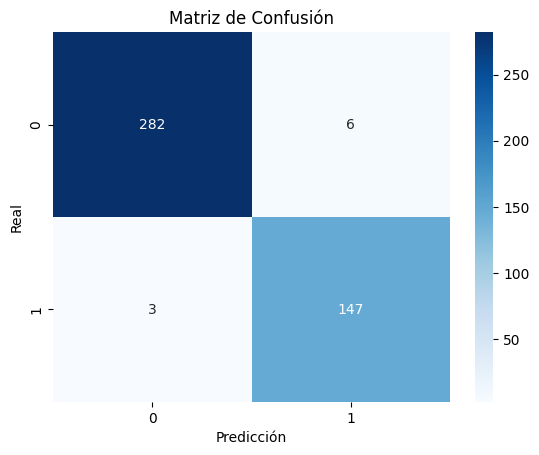

In [22]:
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#### AUROC

Área bajo la curva ROC (AUROC): 0.9989814814814816


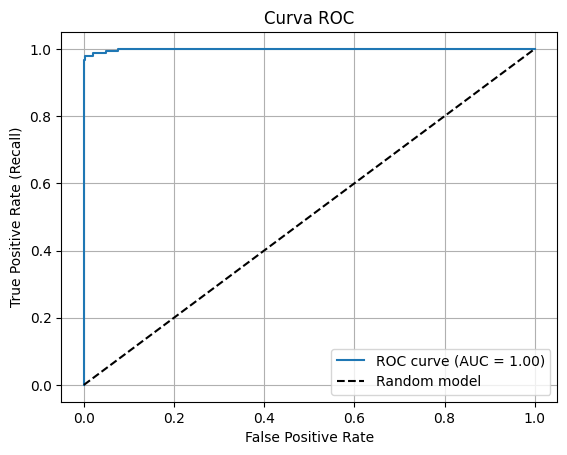

In [23]:
# Cálculo del AUROC
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve

auroc = roc_auc_score(y_test, y_proba)
print("Área bajo la curva ROC (AUROC):", auroc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auroc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()